In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/malaria.zip"
extract_path = "/content/malaria"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print("Location:", extract_path)

Dataset extracted successfully!
Location: /content/malaria


In [9]:
import json
from collections import Counter

json_path = "/content/malaria/malaria/training.json"

with open(json_path, "r") as f:
    data = json.load(f)

counter = Counter()

for item in data:
    for obj in item["objects"]:
        counter[obj["category"]] += 1

print("\nClass Counts:")
for cls, count in counter.items():
    print(f"{cls}: {count}")


Class Counts:
red blood cell: 77420
trophozoite: 1473
schizont: 179
difficult: 441
ring: 353
leukocyte: 103
gametocyte: 144


In [10]:
import json

json_path = "/content/malaria/malaria/training.json"

with open(json_path) as f:
    data = json.load(f)

classes = set()

for item in data:
    for obj in item["objects"]:
        classes.add(obj["category"])

print(classes)

{'leukocyte', 'schizont', 'gametocyte', 'ring', 'trophozoite', 'red blood cell', 'difficult'}


In [11]:
import json
from collections import defaultdict

json_path = "/content/malaria/malaria/training.json"

with open(json_path) as f:
    data = json.load(f)

coexist = defaultdict(int)

for item in data:

    present = set()

    for obj in item["objects"]:
        present.add(obj["category"])

    coexist[tuple(sorted(present))] += 1

print("Unique combinations:\n")

for k, v in coexist.items():
    print(v, "images ->", k)

Unique combinations:

258 images -> ('red blood cell', 'trophozoite')
177 images -> ('red blood cell',)
25 images -> ('difficult', 'red blood cell', 'schizont')
118 images -> ('red blood cell', 'ring')
2 images -> ('difficult', 'leukocyte', 'red blood cell', 'schizont')
124 images -> ('difficult', 'red blood cell')
41 images -> ('gametocyte', 'red blood cell')
37 images -> ('leukocyte', 'red blood cell', 'trophozoite')
28 images -> ('gametocyte', 'red blood cell', 'trophozoite')
3 images -> ('gametocyte', 'red blood cell', 'ring')
54 images -> ('red blood cell', 'ring', 'trophozoite')
12 images -> ('leukocyte', 'red blood cell')
78 images -> ('red blood cell', 'schizont')
12 images -> ('difficult', 'red blood cell', 'schizont', 'trophozoite')
85 images -> ('difficult', 'red blood cell', 'trophozoite')
9 images -> ('leukocyte', 'red blood cell', 'ring', 'trophozoite')
3 images -> ('gametocyte', 'red blood cell', 'schizont')
23 images -> ('red blood cell', 'schizont', 'trophozoite')
10 i

Image: /images/78a5d1c3-44dd-44bc-ad5b-5e25bdcc4fae.png


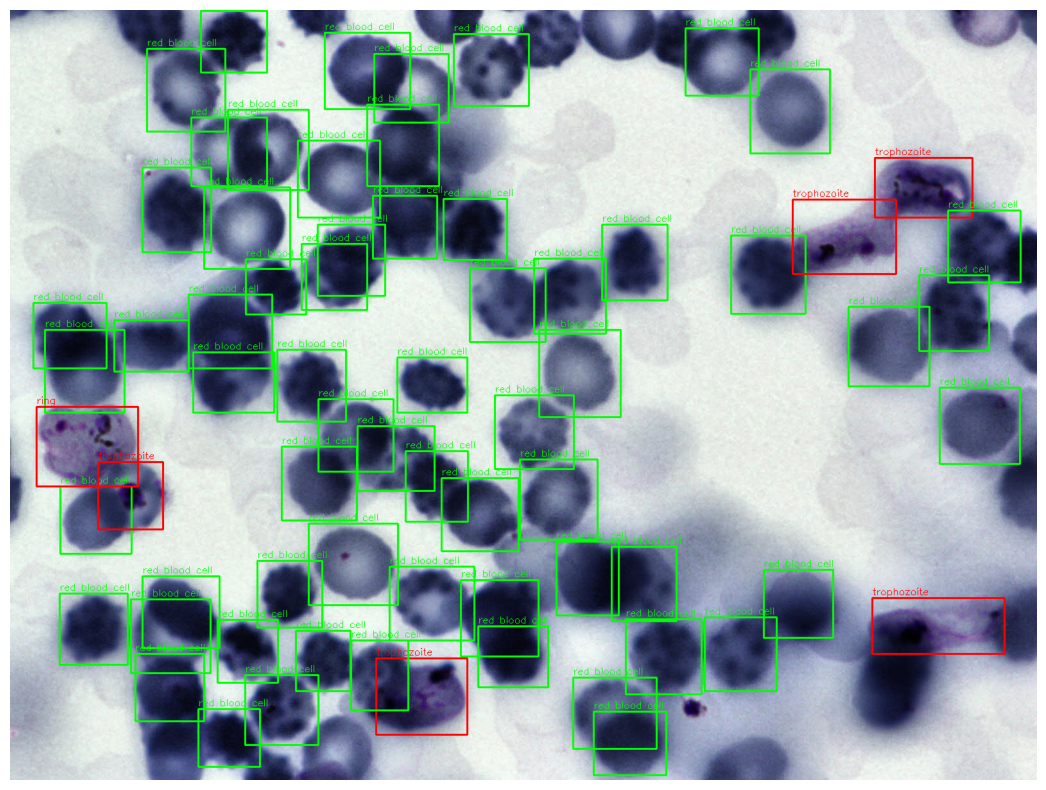

In [12]:
import json
import random
import cv2
import matplotlib.pyplot as plt

json_path = "/content/malaria/malaria/training.json"

with open(json_path) as f:
    data = json.load(f)

parasite_classes = [
    "ring",
    "trophozoite",
    "schizont",
    "gametocyte"
]

samples = []

for item in data:
    classes = [obj["category"] for obj in item["objects"]]

    if any(c in parasite_classes for c in classes):
        samples.append(item)

sample = random.choice(samples)

print("Image:", sample["image"]["pathname"])

img_path = "/content/malaria/malaria/images/" + sample["image"]["pathname"].split("/")[-1]

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

for obj in sample["objects"]:

    x1 = obj["bounding_box"]["minimum"]["c"]
    y1 = obj["bounding_box"]["minimum"]["r"]
    x2 = obj["bounding_box"]["maximum"]["c"]
    y2 = obj["bounding_box"]["maximum"]["r"]

    label = obj["category"]

    if label == "red blood cell":
        color = (0,255,0)
    else:
        color = (255,0,0)

    cv2.rectangle(img,(x1,y1),(x2,y2),color,2)
    cv2.putText(img,label,(x1,y1-5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,color,1)

plt.figure(figsize=(15,10))
plt.imshow(img)
plt.axis("off")
plt.show()

In [13]:
import os

base = "/content/bbbc041_yolo"

folders = [
    "images/train",
    "images/val",
    "labels/train",
    "labels/val"
]

for f in folders:
    os.makedirs(os.path.join(base, f), exist_ok=True)

print("Folders Created")

Folders Created


In [14]:
import json
import os
import cv2
import shutil
from sklearn.model_selection import train_test_split

json_path = "/content/malaria/malaria/training.json"
image_dir = "/content/malaria/malaria/images"

with open(json_path) as f:
    data = json.load(f)

CLASS_MAP = {
    "red blood cell": 0,
    "leukocyte": 1,
    "ring": 2,
    "trophozoite": 2,
    "schizont": 2,
    "gametocyte": 2
}

valid_items = []

for item in data:
    classes = [obj["category"] for obj in item["objects"]]

    if any(c in CLASS_MAP for c in classes):
        valid_items.append(item)

train_data, val_data = train_test_split(
    valid_items,
    test_size=0.2,
    random_state=42
)

print("Train:", len(train_data))
print("Val:", len(val_data))

Train: 966
Val: 242


In [15]:
import os
import cv2
import shutil

base = "/content/bbbc041_yolo"

def convert_dataset(dataset, split):

    for item in dataset:

        image_name = item["image"]["pathname"].split("/")[-1]

        src_img = os.path.join(image_dir, image_name)

        dst_img = os.path.join(
            base,
            f"images/{split}",
            image_name
        )

        shutil.copy(src_img, dst_img)

        img = cv2.imread(src_img)

        h, w = img.shape[:2]

        label_file = os.path.join(
            base,
            f"labels/{split}",
            image_name.replace(".png", ".txt")
        )

        with open(label_file, "w") as f:

            for obj in item["objects"]:

                cls_name = obj["category"]

                if cls_name not in CLASS_MAP:
                    continue

                cls_id = CLASS_MAP[cls_name]

                x1 = obj["bounding_box"]["minimum"]["c"]
                y1 = obj["bounding_box"]["minimum"]["r"]

                x2 = obj["bounding_box"]["maximum"]["c"]
                y2 = obj["bounding_box"]["maximum"]["r"]

                xc = ((x1 + x2) / 2) / w
                yc = ((y1 + y2) / 2) / h

                bw = (x2 - x1) / w
                bh = (y2 - y1) / h

                f.write(
                    f"{cls_id} {xc} {yc} {bw} {bh}\n"
                )

convert_dataset(train_data, "train")
convert_dataset(val_data, "val")

print("YOLO Labels Created")

YOLO Labels Created


In [16]:
import random
import os

label_dir = "/content/bbbc041_yolo/labels/train"

sample = random.choice(os.listdir(label_dir))

print(sample)

with open(os.path.join(label_dir, sample)) as f:
    print(f.read()[:1000])

bb2042c5-35e1-43cc-8171-7de81b764361.txt
0 0.9025 0.36041666666666666 0.06875 0.08083333333333333
0 0.9403125 0.2791666666666667 0.070625 0.09833333333333333
0 0.379375 0.14333333333333334 0.0575 0.07833333333333334
0 0.324375 0.47833333333333333 0.0625 0.07833333333333334
0 0.8725 0.5233333333333333 0.07375 0.09833333333333333
0 0.834375 0.32916666666666666 0.07 0.09166666666666666
0 0.42375 0.7358333333333333 0.065 0.09166666666666666
0 0.5753125 0.51875 0.060625 0.0825
0 0.6534375 0.19375 0.066875 0.09583333333333334
0 0.256875 0.9416666666666667 0.06625 0.095
0 0.045625 0.7620833333333333 0.06125 0.09916666666666667
0 0.36 0.9441666666666667 0.065 0.07333333333333333
0 0.6859375 0.275 0.068125 0.10333333333333333
0 0.2909375 0.8479166666666667 0.066875 0.08416666666666667
0 0.7934375 0.051666666666666666 0.064375 0.085
0 0.760625 0.93125 0.0625 0.08916666666666667
0 0.1921875 0.5816666666666667 0.065625 0.09833333333333333
0 0.6084375 0.11708333333333333 0.058125 0.0825
0 0.1721875

In [17]:
from collections import Counter
import os

label_dir = "/content/bbbc041_yolo/labels/train"

counter = Counter()

for file in os.listdir(label_dir):

    with open(os.path.join(label_dir, file)) as f:

        for line in f:

            cls = int(line.split()[0])

            counter[cls] += 1

print(counter)

Counter({0: 60973, 2: 1730, 1: 86})


In [18]:
import os

train_imgs = len(os.listdir("/content/bbbc041_yolo/images/train"))
train_lbls = len(os.listdir("/content/bbbc041_yolo/labels/train"))

val_imgs = len(os.listdir("/content/bbbc041_yolo/images/val"))
val_lbls = len(os.listdir("/content/bbbc041_yolo/labels/val"))

print("Train Images:", train_imgs)
print("Train Labels:", train_lbls)

print("Val Images:", val_imgs)
print("Val Labels:", val_lbls)

Train Images: 966
Train Labels: 966
Val Images: 242
Val Labels: 242


In [20]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="QEDnsKG5GVYtuTA7Uxp3")
project = rf.workspace("team-roboflow").project("blood-cell-detection-1ekwu")
version = project.version(3)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 103.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Blood-Cell-Detection-3 in yolov8:: 100%|██████████| 740/740 [00:00<00:00, 12073.65it/s]


In [21]:
import os

base = "/content/final_dataset"

for folder in [
    "images/train",
    "images/val",
    "labels/train",
    "labels/val"
]:
    os.makedirs(os.path.join(base, folder), exist_ok=True)

print("Final Dataset Created")

Final Dataset Created


In [22]:
import shutil
import os

src_base = "/content/bbbc041_yolo"
dst_base = "/content/final_dataset"

for split in ["train", "val"]:

    img_src = os.path.join(src_base, f"images/{split}")
    lbl_src = os.path.join(src_base, f"labels/{split}")

    img_dst = os.path.join(dst_base, f"images/{split}")
    lbl_dst = os.path.join(dst_base, f"labels/{split}")

    for file in os.listdir(img_src):
        shutil.copy(
            os.path.join(img_src,file),
            os.path.join(img_dst,f"malaria_{file}")
        )

    for file in os.listdir(lbl_src):
        shutil.copy(
            os.path.join(lbl_src,file),
            os.path.join(lbl_dst,f"malaria_{file}")
        )

print("BBBC041 merged")

BBBC041 merged


In [23]:
import os
import shutil

BCCD_MAP = {
    0: 2,  # Platelet
    1: 0,  # RBC
    2: 1   # WBC
}

bccd_root = "/content/Blood-Cell-Detection-3"
final_root = "/content/final_dataset"

splits = {
    "train":"train",
    "valid":"val"
}

for src_split,dst_split in splits.items():

    img_src = os.path.join(
        bccd_root,
        src_split,
        "images"
    )

    lbl_src = os.path.join(
        bccd_root,
        src_split,
        "labels"
    )

    img_dst = os.path.join(
        final_root,
        f"images/{dst_split}"
    )

    lbl_dst = os.path.join(
        final_root,
        f"labels/{dst_split}"
    )

    for img_file in os.listdir(img_src):

        shutil.copy(
            os.path.join(img_src,img_file),
            os.path.join(
                img_dst,
                f"bccd_{img_file}"
            )
        )

    for lbl_file in os.listdir(lbl_src):

        src_label = os.path.join(
            lbl_src,
            lbl_file
        )

        dst_label = os.path.join(
            lbl_dst,
            f"bccd_{lbl_file}"
        )

        with open(src_label) as f:
            lines = f.readlines()

        new_lines = []

        for line in lines:

            parts = line.strip().split()

            old_cls = int(parts[0])

            parts[0] = str(
                BCCD_MAP[old_cls]
            )

            new_lines.append(
                " ".join(parts)
            )

        with open(dst_label,"w") as f:
            f.write(
                "\n".join(new_lines)
            )

print("BCCD merged")

BCCD merged


In [24]:
from collections import Counter
import os

counter = Counter()

for split in ["train","val"]:

    label_dir = f"/content/final_dataset/labels/{split}"

    for file in os.listdir(label_dir):

        with open(os.path.join(label_dir,file)) as f:

            for line in f:

                cls = int(
                    line.split()[0]
                )

                counter[cls]+=1

print(counter)

Counter({0: 81175, 2: 2474, 1: 438})


In [25]:
from collections import Counter
import os

counter = Counter()

for split in ["train","val"]:

    label_dir = f"/content/bbbc041_yolo/labels/{split}"

    for file in os.listdir(label_dir):

        with open(os.path.join(label_dir,file)) as f:

            for line in f:

                cls = int(line.split()[0])

                counter[cls]+=1

print(counter)

Counter({0: 77420, 2: 2149, 1: 103})


In [26]:
parasite_count = 0

for split in ["train","val"]:

    label_dir = f"/content/final_dataset/labels/{split}"

    for file in os.listdir(label_dir):

        with open(os.path.join(label_dir,file)) as f:

            for line in f:

                if int(line.split()[0]) == 3:
                    parasite_count += 1

print("Parasite Objects:", parasite_count)

Parasite Objects: 0


In [27]:
import random
import os

label_dir = "/content/final_dataset/labels/train"

malaria_files = [
    f for f in os.listdir(label_dir)
    if f.startswith("malaria_")
]

sample = random.choice(malaria_files)

print(sample)

with open(os.path.join(label_dir,sample)) as f:
    print(f.read()[:1000])

malaria_e9916e11-9be6-4dec-9df6-2e7d1a8e1735.txt
0 0.65125 0.92625 0.06125 0.0875
0 0.4690625 0.9375 0.074375 0.09166666666666666
0 0.4953125 0.36 0.070625 0.11166666666666666
0 0.3628125 0.435 0.060625 0.08833333333333333
0 0.5440625 0.58375 0.081875 0.08083333333333333
0 0.8515625 0.6104166666666667 0.075625 0.0925
0 0.2828125 0.6404166666666666 0.070625 0.0925
2 0.69125 0.25875 0.08125 0.1075
0 0.7928125 0.7245833333333334 0.064375 0.09583333333333334
0 0.494375 0.8379166666666666 0.05875 0.08916666666666667
0 0.5803125 0.79375 0.070625 0.0925
0 0.2090625 0.8416666666666667 0.064375 0.10333333333333333
0 0.1171875 0.34375 0.068125 0.0875
0 0.3109375 0.1675 0.073125 0.11
0 0.2284375 0.9233333333333333 0.071875 0.09166666666666666
0 0.960625 0.615 0.0675 0.09333333333333334
0 0.83625 0.1825 0.06625 0.09
0 0.425625 0.7595833333333334 0.075 0.09583333333333334
0 0.5875 0.6591666666666667 0.0675 0.08
0 0.2996875 0.30125 0.071875 0.11083333333333334
0 0.2071875 0.5395833333333333 0.068125

In [28]:
from collections import Counter
import os

counter = Counter()

for split in ["train", "val"]:

    label_dir = f"/content/bbbc041_yolo/labels/{split}"

    for file in os.listdir(label_dir):

        with open(os.path.join(label_dir,file)) as f:

            for line in f:

                cls = int(line.split()[0])

                counter[cls] += 1

print(counter)

Counter({0: 77420, 2: 2149, 1: 103})


In [29]:
import os

found = False

for split in ["train","val"]:

    label_dir = f"/content/bbbc041_yolo/labels/{split}"

    for file in os.listdir(label_dir):

        with open(os.path.join(label_dir,file)) as f:

            content = f.read()

            if "\n2 " in "\n" + content:
                print("Found parasite:", file)
                found = True
                break

    if found:
        break

if not found:
    print("No parasite labels found")

Found parasite: 0ed416f9-7c20-4829-9016-559e4009568e.txt


In [30]:
import os

for split in ["train", "val"]:

    label_dir = f"/content/final_dataset/labels/{split}"

    for file in os.listdir(label_dir):

        if not file.startswith("malaria_"):
            continue

        path = os.path.join(label_dir, file)

        with open(path, "r") as f:
            lines = f.readlines()

        new_lines = []

        for line in lines:

            parts = line.strip().split()

            cls = int(parts[0])

            # malaria dataset mapping
            if cls == 2:
                cls = 3

            parts[0] = str(cls)

            new_lines.append(" ".join(parts))

        with open(path, "w") as f:
            f.write("\n".join(new_lines))

In [31]:
from collections import Counter
import os

counter = Counter()

for split in ["train","val"]:

    label_dir = f"/content/final_dataset/labels/{split}"

    for file in os.listdir(label_dir):

        with open(os.path.join(label_dir,file)) as f:

            for line in f:
                counter[int(line.split()[0])] += 1

print(counter)

Counter({0: 81175, 3: 2149, 1: 438, 2: 325})


In [32]:
yaml_text = """
path: /content/final_dataset

train: images/train
val: images/val

names:
  0: RBC
  1: WBC
  2: Platelet
  3: Parasite
"""

with open("/content/final_dataset/data.yaml", "w") as f:
    f.write(yaml_text)

print("Final YAML Created")

Final YAML Created


In [33]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.9 MB/s eta 0:00:00


In [34]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [35]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [11]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")

results = model.train(
    data="/content/final_dataset/data.yaml",
    epochs=40,          # continue only 15-20 more epochs
    imgsz=640,
    batch=16,
    workers=8,
    cache="ram",
    device=0,
    pretrained=False,
    project="blood_cell_project",
    name="blood_detector_v1"



)

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/final_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=blood_detector_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat

In [12]:
import shutil

shutil.copy(
    "/content/runs/detect/blood_cell_project/blood_detector_v1/weights/best.pt",
    "/content/drive/MyDrive/blood_cell_best.pt"
)

print("Saved")

Saved


In [13]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/blood_cell_best.pt")

results = model.predict(
    source="/content/final_dataset/images/val",
    conf=0.25,
    save=True
)


image 1/315 /content/final_dataset/images/val/bccd_BloodImage_00000_jpg.rf.b9b54ee242858a8aa6282ee25f3c06d0.jpg: 640x640 19 RBCs, 1 WBC, 15.5ms
image 2/315 /content/final_dataset/images/val/bccd_BloodImage_00004_jpg.rf.32f80737b874b0728582d77e7c409dd5.jpg: 640x640 11 RBCs, 1 WBC, 1 Platelet, 15.5ms
image 3/315 /content/final_dataset/images/val/bccd_BloodImage_00012_jpg.rf.c13d42e1d82ce2884cb53e803eef77c2.jpg: 640x640 16 RBCs, 1 WBC, 2 Platelets, 15.6ms
image 4/315 /content/final_dataset/images/val/bccd_BloodImage_00017_jpg.rf.4cfec76b2314dcd5ec636e88022a15c4.jpg: 640x640 18 RBCs, 1 WBC, 1 Platelet, 16.0ms
image 5/315 /content/final_dataset/images/val/bccd_BloodImage_00021_jpg.rf.958b85e69293875ea481e8913fd7f93d.jpg: 640x640 17 RBCs, 1 WBC, 2 Platelets, 15.5ms
image 6/315 /content/final_dataset/images/val/bccd_BloodImage_00026_jpg.rf.d333bd592474ebab9260e51498f1f9c2.jpg: 640x640 20 RBCs, 1 WBC, 1 Platelet, 15.5ms
image 7/315 /content/final_dataset/images/val/bccd_BloodImage_00050_jpg.r

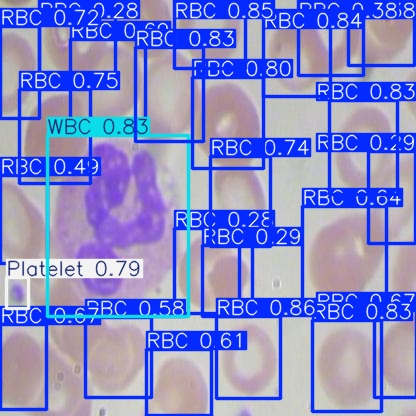

In [14]:
from IPython.display import Image, display
import os

pred_dir = "/content/runs/detect/predict"

sample = os.listdir(pred_dir)[0]

display(Image(os.path.join(pred_dir, sample)))

In [15]:
import os

pred_dir = "/content/runs/detect/predict"

print(os.listdir(pred_dir)[:10])

['bccd_BloodImage_00245_jpg.rf.7a0f1753d63bc71debb24d55784325d9.jpg', 'malaria_105af41b-13cc-4ad1-8a1f-8bc4d47cdd94.jpg', 'bccd_BloodImage_00403_jpg.rf.1b029d5c33744ac09b147afe95897162.jpg', 'bccd_BloodImage_00228_jpg.rf.a0cd74f136d6df4840a42ff71d99639a.jpg', 'malaria_04018590-4e66-4cb9-ad2d-83570f1b29ae.jpg', 'malaria_83ec8923-6232-40d7-ba1f-a1b8bf7cb66c.jpg', 'malaria_f24c8fe0-a534-44cf-9995-b2b314d945ba.jpg', 'malaria_161978c3-3a05-47a5-9fee-be7d25693eae.jpg', 'malaria_b59dc3a0-3d54-4e3b-a485-33b3e43966de.jpg', 'malaria_50d7c6c9-3230-48fe-947c-7dcfd0aad710.jpg']


In [16]:
import os

pred_dir = "/content/runs/detect/predict"

print(os.listdir(pred_dir)[:10])

['bccd_BloodImage_00245_jpg.rf.7a0f1753d63bc71debb24d55784325d9.jpg', 'malaria_105af41b-13cc-4ad1-8a1f-8bc4d47cdd94.jpg', 'bccd_BloodImage_00403_jpg.rf.1b029d5c33744ac09b147afe95897162.jpg', 'bccd_BloodImage_00228_jpg.rf.a0cd74f136d6df4840a42ff71d99639a.jpg', 'malaria_04018590-4e66-4cb9-ad2d-83570f1b29ae.jpg', 'malaria_83ec8923-6232-40d7-ba1f-a1b8bf7cb66c.jpg', 'malaria_f24c8fe0-a534-44cf-9995-b2b314d945ba.jpg', 'malaria_161978c3-3a05-47a5-9fee-be7d25693eae.jpg', 'malaria_b59dc3a0-3d54-4e3b-a485-33b3e43966de.jpg', 'malaria_50d7c6c9-3230-48fe-947c-7dcfd0aad710.jpg']


In [17]:
import shutil

shutil.copy(
    "/content/runs/detect/blood_cell_project/blood_detector_v1/weights/best.pt",
    "/content/drive/MyDrive/blood_cell_best.pt"
)

print("best.pt saved to Drive")

best.pt saved to Drive


In [18]:
import os

run_dir = "/content/runs/detect/blood_cell_project/blood_detector_v1"

for f in os.listdir(run_dir):
    print(f)

confusion_matrix.png
val_batch0_pred.jpg
val_batch1_labels.jpg
train_batch0.jpg
val_batch2_pred.jpg
BoxPR_curve.png
confusion_matrix_normalized.png
results.png
val_batch1_pred.jpg
BoxP_curve.png
args.yaml
val_batch2_labels.jpg
train_batch2311.jpg
train_batch2.jpg
BoxF1_curve.png
weights
results.csv
BoxR_curve.png
train_batch2310.jpg
val_batch0_labels.jpg
train_batch2312.jpg
train_batch1.jpg
labels.jpg


In [19]:
import shutil
import os

src = "/content/runs/detect/blood_cell_project/blood_detector_v1"
dst = "/content/drive/MyDrive/Blood_Cell_Project_Results"

os.makedirs(dst, exist_ok=True)

for file in os.listdir(src):
    full_path = os.path.join(src, file)

    if os.path.isfile(full_path):
        shutil.copy(full_path, dst)

print("Graphs and results saved")

Graphs and results saved


In [20]:
import shutil

shutil.copytree(
    "/content/runs/detect/blood_cell_project/blood_detector_v1",
    "/content/drive/MyDrive/Blood_Cell_Project_Full_Run",
    dirs_exist_ok=True
)

print("Full training folder saved")

Full training folder saved


In [21]:
!zip -r /content/final_dataset.zip /content/final_dataset

  adding: content/final_dataset/ (stored 0%)
  adding: content/final_dataset/labels/ (stored 0%)
  adding: content/final_dataset/labels/train.cache (deflated 59%)
  adding: content/final_dataset/labels/train/ (stored 0%)
  adding: content/final_dataset/labels/train/bccd_BloodImage_00333_jpg.rf.e52165fef9a61a53dbe4b7ac0602076e.txt (deflated 74%)
  adding: content/final_dataset/labels/train/malaria_d7581cb0-7a12-471d-a3d8-68dcea362213.txt (deflated 77%)
  adding: content/final_dataset/labels/train/malaria_07a80340-f65e-4f58-9317-94bb6ebd5a28.txt (deflated 78%)
  adding: content/final_dataset/labels/train/malaria_c66cb6b2-1480-446a-a9d2-b8032a3de0d7.txt (deflated 77%)
  adding: content/final_dataset/labels/train/malaria_6b2ff7ca-c5b3-415c-9481-7b14efc6d7ef.txt (deflated 77%)
  adding: content/final_dataset/labels/train/malaria_d6942996-5664-4370-ad87-2bdcbd49ac16.txt (deflated 77%)
  adding: content/final_dataset/labels/train/malaria_c3042130-a6e2-458f-9fde-bb012f68f5f2.txt (deflated 77%)

In [22]:
import shutil

shutil.copy(
    "/content/final_dataset.zip",
    "/content/drive/MyDrive/final_dataset.zip"
)

print("Dataset saved")

Dataset saved


In [1]:
from ultralytics import YOLO

model = YOLO("yolo11m.pt")

model.train(
    data="/content/final_dataset/data.yaml",
    epochs=40,
    imgsz=800,
    batch=8,
    device=0,
    cache=True,
    workers=4,
    project="blood_cell_project",
    name="blood_detector_v2_m800"
)

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/final_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=blood_detector_v2_m800-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7de39c0371d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [2]:
import os

SAVE_DIR = "/content/drive/MyDrive/Blood_Cell_Project_V2"

os.makedirs(SAVE_DIR, exist_ok=True)

print("Folder Created")

Folder Created


In [3]:
import shutil

src = "/content/runs/detect/blood_cell_project/blood_detector_v2_m800-2"

dst = "/content/drive/MyDrive/Blood_Cell_Project_V2/training_results"

shutil.copytree(src, dst, dirs_exist_ok=True)

print("Training Results Saved")

Training Results Saved


In [4]:
import shutil

shutil.copy(
    "/content/runs/detect/blood_cell_project/blood_detector_v2_m800-2/weights/best.pt",
    "/content/drive/MyDrive/Blood_Cell_Project_V2/best_v2.pt"
)

print("best.pt Saved")

best.pt Saved


In [5]:
shutil.copy(
    "/content/runs/detect/blood_cell_project/blood_detector_v2_m800-2/weights/last.pt",
    "/content/drive/MyDrive/Blood_Cell_Project_V2/last_v2.pt"
)

print("last.pt Saved")

last.pt Saved


In [6]:
summary = """
Blood Cell Detection System V2

Model:
YOLO11m

Image Size:
800

Epochs:
40

Classes:
0 RBC
1 WBC
2 Platelet
3 Parasite

Results:

Precision = 0.898
Recall = 0.956
mAP50 = 0.961
mAP50-95 = 0.730

Dataset:
Merged BCCD + Malaria Dataset

Date:
June 2026
"""

with open("/content/model_summary_v2.txt","w") as f:
    f.write(summary)

print("Summary Created")

Summary Created


In [7]:
shutil.copy(
    "/content/model_summary_v2.txt",
    "/content/drive/MyDrive/Blood_Cell_Project_V2/model_summary_v2.txt"
)

'/content/drive/MyDrive/Blood_Cell_Project_V2/model_summary_v2.txt'